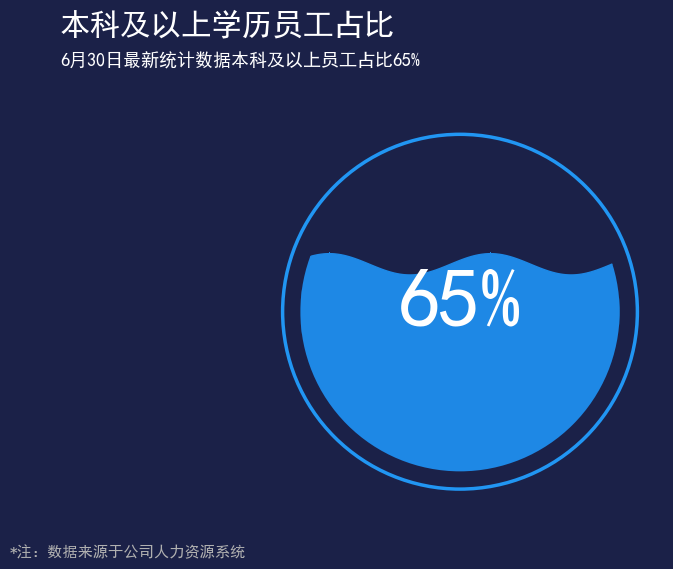

In [27]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Circle

plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei']
plt.rcParams['axes.unicode_minus'] = False

BG    = '#1b2148' 
TEXT  = '#ffffff'
SUB   = '#B0B0B0'
WATER = '#1E88E5'
RING  = '#2196F3'

value = 0.65
R_OUTER = 1.00
R_INNER = 0.90 

fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor(BG)
ax.set_facecolor(BG)
fig.subplots_adjust(left=0.05, right=0.95, top=0.78, bottom=0.10)

ax.add_patch(Circle((0, 0), R_OUTER, facecolor='none', edgecolor=RING, linewidth=2.5, zorder=4))

y_base = -R_INNER + 2 * R_INNER * value

xw = np.linspace(-R_INNER, R_INNER, 800)
yw = y_base + 0.06 * np.sin(2.2 * xw * np.pi + 0.4)

poly = ax.fill_between(xw, -R_INNER - 0.2, yw, color=WATER, zorder=3)
clip_circle = Circle((0, 0), R_INNER, transform=ax.transData)
poly.set_clip_path(clip_circle)

ax.text(0, 0.05, f'{value:.0%}', ha='center', va='center', fontsize=60, fontweight='bold', color=TEXT, zorder=10)

ax.set_xlim(-1.15, 1.15)
ax.set_ylim(-1.15, 1.15)
ax.set_aspect('equal')
ax.axis('off')

fig.text(0.1, 0.92, '本科及以上学历员工占比',
         ha='left', va='center', fontsize=22, fontweight='bold', color=TEXT)
fig.text(0.1, 0.86, '6月30日最新统计数据本科及以上员工占比65%', ha='left', va='center', fontsize=13, color=TEXT)

fig.text(0.05, 0.04, '*注：数据来源于公司人力资源系统', ha='left', va='center', fontsize=11, color=SUB)

plt.savefig("16 波浪水球图.png", facecolor=BG, dpi=200)

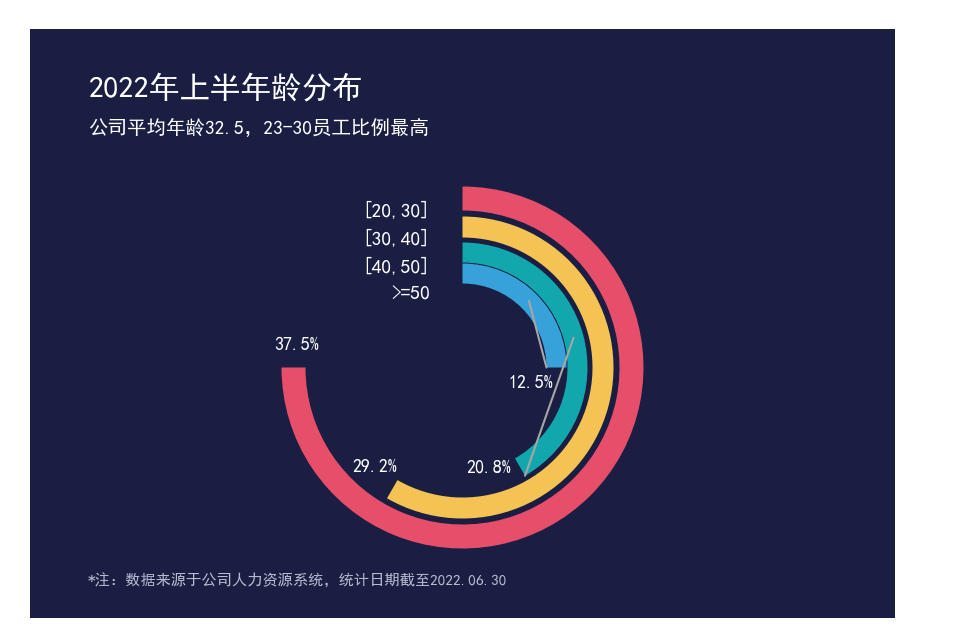

In [28]:
import math
import matplotlib.pyplot as plt
from matplotlib.patches import Wedge, Rectangle

plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei']
plt.rcParams['axes.unicode_minus'] = False

BG     = "#1A1E43"
RED    = "#E74E69"
YELLOW = "#F5C353"
TEAL   = "#11A7AD"
BLUE   = "#37A2DA"
GREY   = "#B9BAD0"
LINE   = "#A6A6A6"    

END_DEG = -90.0
rings = [
    (181.0, 24.0, RED,    180.0),
    (151.0, 21.0, YELLOW, 120.0),
    (125.0, 20.0, TEAL,    60.0),
    (104.0, 20.0, BLUE,     0.0)]

W_PX, H_PX = 935.0, 621.0
fig = plt.figure(figsize=(W_PX / 100.0, H_PX / 100.0), dpi=100)
fig.patch.set_facecolor("white")
ax = fig.add_axes([0, 0, 1, 1])
ax.set_xlim(0, W_PX)
ax.set_ylim(H_PX, 0)
ax.set_aspect("equal")
ax.axis("off")

ax.add_patch(Rectangle((20, 20), 865, 589, facecolor=BG, edgecolor="none"))

CX, CY = 452.5, 358.5

def pol(r, deg):
    a = math.radians(deg)
    return CX + r * math.cos(a), CY + r * math.sin(a)

for R, lw, color, start in rings:
    ax.add_patch(Wedge((CX, CY), R, END_DEG, start, width=lw,
                       facecolor=color, edgecolor=BG, linewidth=0))

RING = {color: {"out": R, "inner": R - lw, "mid": R - lw / 2.0, "start": start}
        for R, lw, color, start in rings}

ax.text(78, 78, "2022年上半年龄分布", color="white", fontsize=22,
        ha="left", va="center")
ax.text(78, 118, "公司平均年龄32.5，23-30员工比例最高", color="white",
        fontsize=14, ha="left", va="center")

ly = 200.0
for text in ["[20,30]", "[30,40]", "[40,50]", ">=50"]:
    ax.text(420, ly, text, color="white", fontsize=14,
            ha="right", va="center", zorder=7)
    ly += 28.0

label = {
    "37.5%": (286.5, 335.0),
    "29.2%": (364.5, 456.5),
    "20.8%": (478.5, 456.5),
    "12.5%": (520.5, 373.0)}

LEADER = {
    "20.8%": {"ring": TEAL, "edge": "out"},   
    "12.5%": {"ring": BLUE, "edge": "inner"}}

for val, spec in LEADER.items():
    g = RING[spec["ring"]]
    r_from = g[spec["edge"]]                    
    deg_from = g["start"]                        
    r_to = g["mid"]                               
    deg_to = (END_DEG + g["start"]) / 2.0          

    p1 = pol(r_from, deg_from)
    p2 = pol(r_to, deg_to)
    ax.plot([p1[0], p2[0]], [p1[1], p2[1]],
            color=LINE, lw=1.5, solid_capstyle="round", zorder=5)

for val, (x, y) in label.items():
    ax.text(x, y, val, color="white", fontsize=13,
            ha="center", va="center", zorder=6)

ax.text(78, 570, "*注：数据来源于公司人力资源系统，统计日期截至2022.06.30",
        color=GREY, fontsize=11, ha="left", va="center")

fig.savefig("17 玉块图.png", facecolor="white", dpi=200)

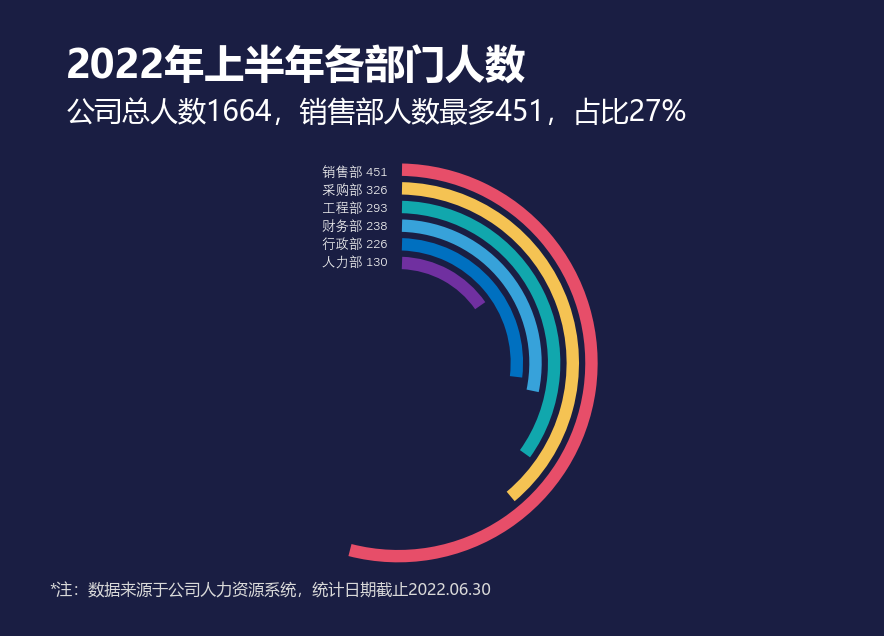

In [39]:
import math
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, Wedge

plt.rcParams["font.sans-serif"] = ["Microsoft YaHei", "DengXian"]
plt.rcParams["axes.unicode_minus"] = False

BG = "#1A1E43"
TITLE_C = "#FFFFFF"
SUB_C = "#FFFFFF"
LEG_C = "#F2F2F2"
NOTE_C = "#D9D9D9"

DEPT = [
    ("销售部", 451, "#E74E69"),
    ("采购部", 326, "#F5C353"),
    ("工程部", 293, "#11A7AD"),
    ("财务部", 238, "#37A2DA"),
    ("行政部", 226, "#0070C0"),
    ("人力部", 130, "#7030A0")]

TITLE = "2022年上半年各部门人数"
SUBTITLE = "公司总人数1664，销售部人数最多451，占比27%"
FOOTNOTE = "*注：数据来源于公司人力资源系统，统计日期截止2022.06.30"

CW, CH = 864.0, 616.0
CX, CY = 388.2, 352.9
R_OUT, R_STEP, R_W = 199.45, 18.65, 12.4
CUT_DX = 3.8
DEG_PER_PERSON = 0.4374
DEG_OFFSET = -3.94

TITLE_XY, TITLE_FS = (55.5, 57.4), 28.9
SUB_XY, SUB_FS = (56.5, 102.7), 20.16
LEG_X, LEG_Y0, LEG_DY, LEG_FS = 311.5, 162.8, 18.0, 9.7
NOTE_XY, NOTE_FS = (39.0, 580.5), 11.52

TITLE_FAM = ["Microsoft YaHei", "DengXian"]
LEG_FAM = ["DengXian", "Microsoft YaHei"]


def ring_geometry():
    rings = []
    for i, (name, value, color) in enumerate(DEPT):
        r_out = R_OUT - i * R_STEP
        r_mid = r_out - R_W / 2.0
        start = -math.degrees(math.acos(CUT_DX / r_mid))
        sweep = value * DEG_PER_PERSON + DEG_OFFSET
        rings.append((r_out, start, start + sweep, color))
    return rings


fig = plt.figure(figsize=(CW / 100.0, CH / 100.0), dpi=100, facecolor=BG)
ax = fig.add_axes([0, 0, 1, 1], facecolor=BG)
ax.set_xlim(0, CW)
ax.set_ylim(CH, 0)
ax.set_aspect("equal")
ax.axis("off")

ax.add_patch(Rectangle((0, 0), CW, CH, facecolor=BG, edgecolor="none"))

for r_out, start, end, color in ring_geometry():
    ax.add_patch(Wedge((CX, CY), r_out, start, end, width=R_W,
                       facecolor=color, edgecolor="none", linewidth=0))

ax.text(TITLE_XY[0], TITLE_XY[1], TITLE, color=TITLE_C, fontsize=TITLE_FS,
        fontfamily=TITLE_FAM, fontweight="bold", ha="left", va="center")
ax.text(SUB_XY[0], SUB_XY[1], SUBTITLE, color=SUB_C, fontsize=SUB_FS,
        fontfamily=TITLE_FAM, ha="left", va="center")

for i, (name, value, _) in enumerate(DEPT):
    ax.text(LEG_X, LEG_Y0 + i * LEG_DY, "%s %d" % (name, value), color=LEG_C,
            fontsize=LEG_FS, fontfamily=LEG_FAM, ha="left", va="center")

ax.text(NOTE_XY[0], NOTE_XY[1], FOOTNOTE, color=NOTE_C, fontsize=NOTE_FS,
        fontfamily=TITLE_FAM, ha="left", va="center")

fig.savefig("18 跑道图.png", facecolor=BG, dpi=200)

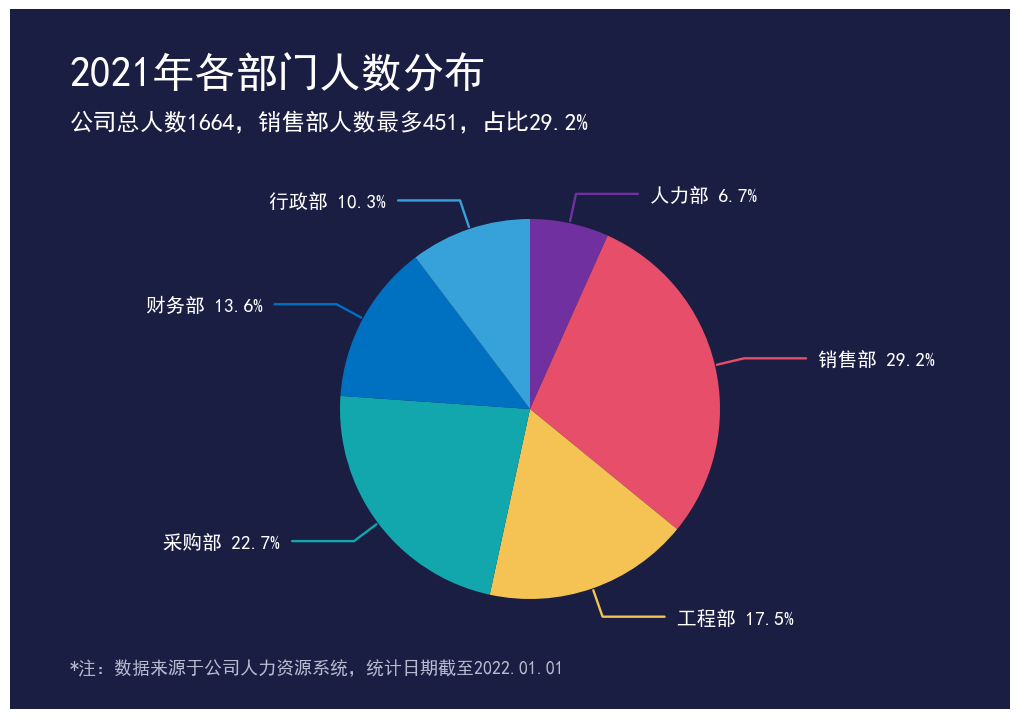

In [29]:
import math
import matplotlib
import matplotlib.pyplot as plt
from matplotlib import font_manager
from matplotlib.patches import Wedge, Rectangle, Circle

plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei']
plt.rcParams['axes.unicode_minus'] = False

BG     = "#1A1E43"
RED    = "#E74E69"
YELLOW = "#F5C353"
TEAL   = "#11A7AD"
DBLUE  = "#0070C0"
MBLUE  = "#37A2DA"
PURPLE = "#7030A0"
GREY   = "#B9BAD0"

data = [
    ("人力部",  6.7, PURPLE),
    ("销售部", 29.2, RED),
    ("工程部", 17.5, YELLOW),
    ("采购部", 22.7, TEAL),
    ("财务部", 13.6, DBLUE),
    ("行政部", 10.3, MBLUE)]

W_PX, H_PX = 1000.0, 700.0
fig = plt.figure(figsize=(W_PX / 100.0, H_PX / 100.0), dpi=100)
fig.patch.set_facecolor("white")
ax = fig.add_axes([0, 0, 1, 1])
ax.set_xlim(0, W_PX)
ax.set_ylim(H_PX, 0)              
ax.set_aspect("equal")
ax.axis("off")

ax.add_patch(Rectangle((0, 0), W_PX, H_PX, facecolor=BG, edgecolor="none"))

CX, CY, R = 520.0, 400.0, 190.0 

START = -90.0
deg = START
pie_mids = []
for name, pct, color in data:
    span = 360.0 * pct / 100.0
    a1, a2 = deg, deg + span
    ax.add_patch(Wedge((CX, CY), R, a1, a2, facecolor=color,
                       edgecolor="none", linewidth=0))
    pie_mids.append(((a1 + a2) / 2.0, name, pct, color))
    deg = a2

ax.text(60, 62, "2021年各部门人数分布", color="white", fontsize=30,
        fontweight="bold", ha="left", va="center")
ax.text(60, 112, "公司总人数1664，销售部人数最多451，占比29.2%", color="white",
        fontsize=17, ha="left", va="center")


def pol(r, d):
    a = math.radians(d)
    return CX + r * math.cos(a), CY + r * math.sin(a)

for mid, name, pct, color in pie_mids:
    x1, y1 = pol(R + 2, mid)          
    x2, y2 = pol(R + 30, mid)           
    side = -1 if x2 < CX else 1
    x3 = x2 + side * 62              

    ax.plot([x1, x2, x3], [y1, y2, y2], color=color, lw=1.7,
            solid_capstyle="round", zorder=5)

    tx = x3 + side * 12
    ax.text(tx, y2, f"{name} {pct}%", color="white", fontsize=14,
            ha="left" if side > 0 else "right", va="center", zorder=6)

ax.text(60, H_PX - 42, "*注：数据来源于公司人力资源系统，统计日期截至2022.01.01",
        color=GREY, fontsize=13, ha="left", va="center")

fig.savefig("19 南丁格尔圆饼图.png", facecolor="white")

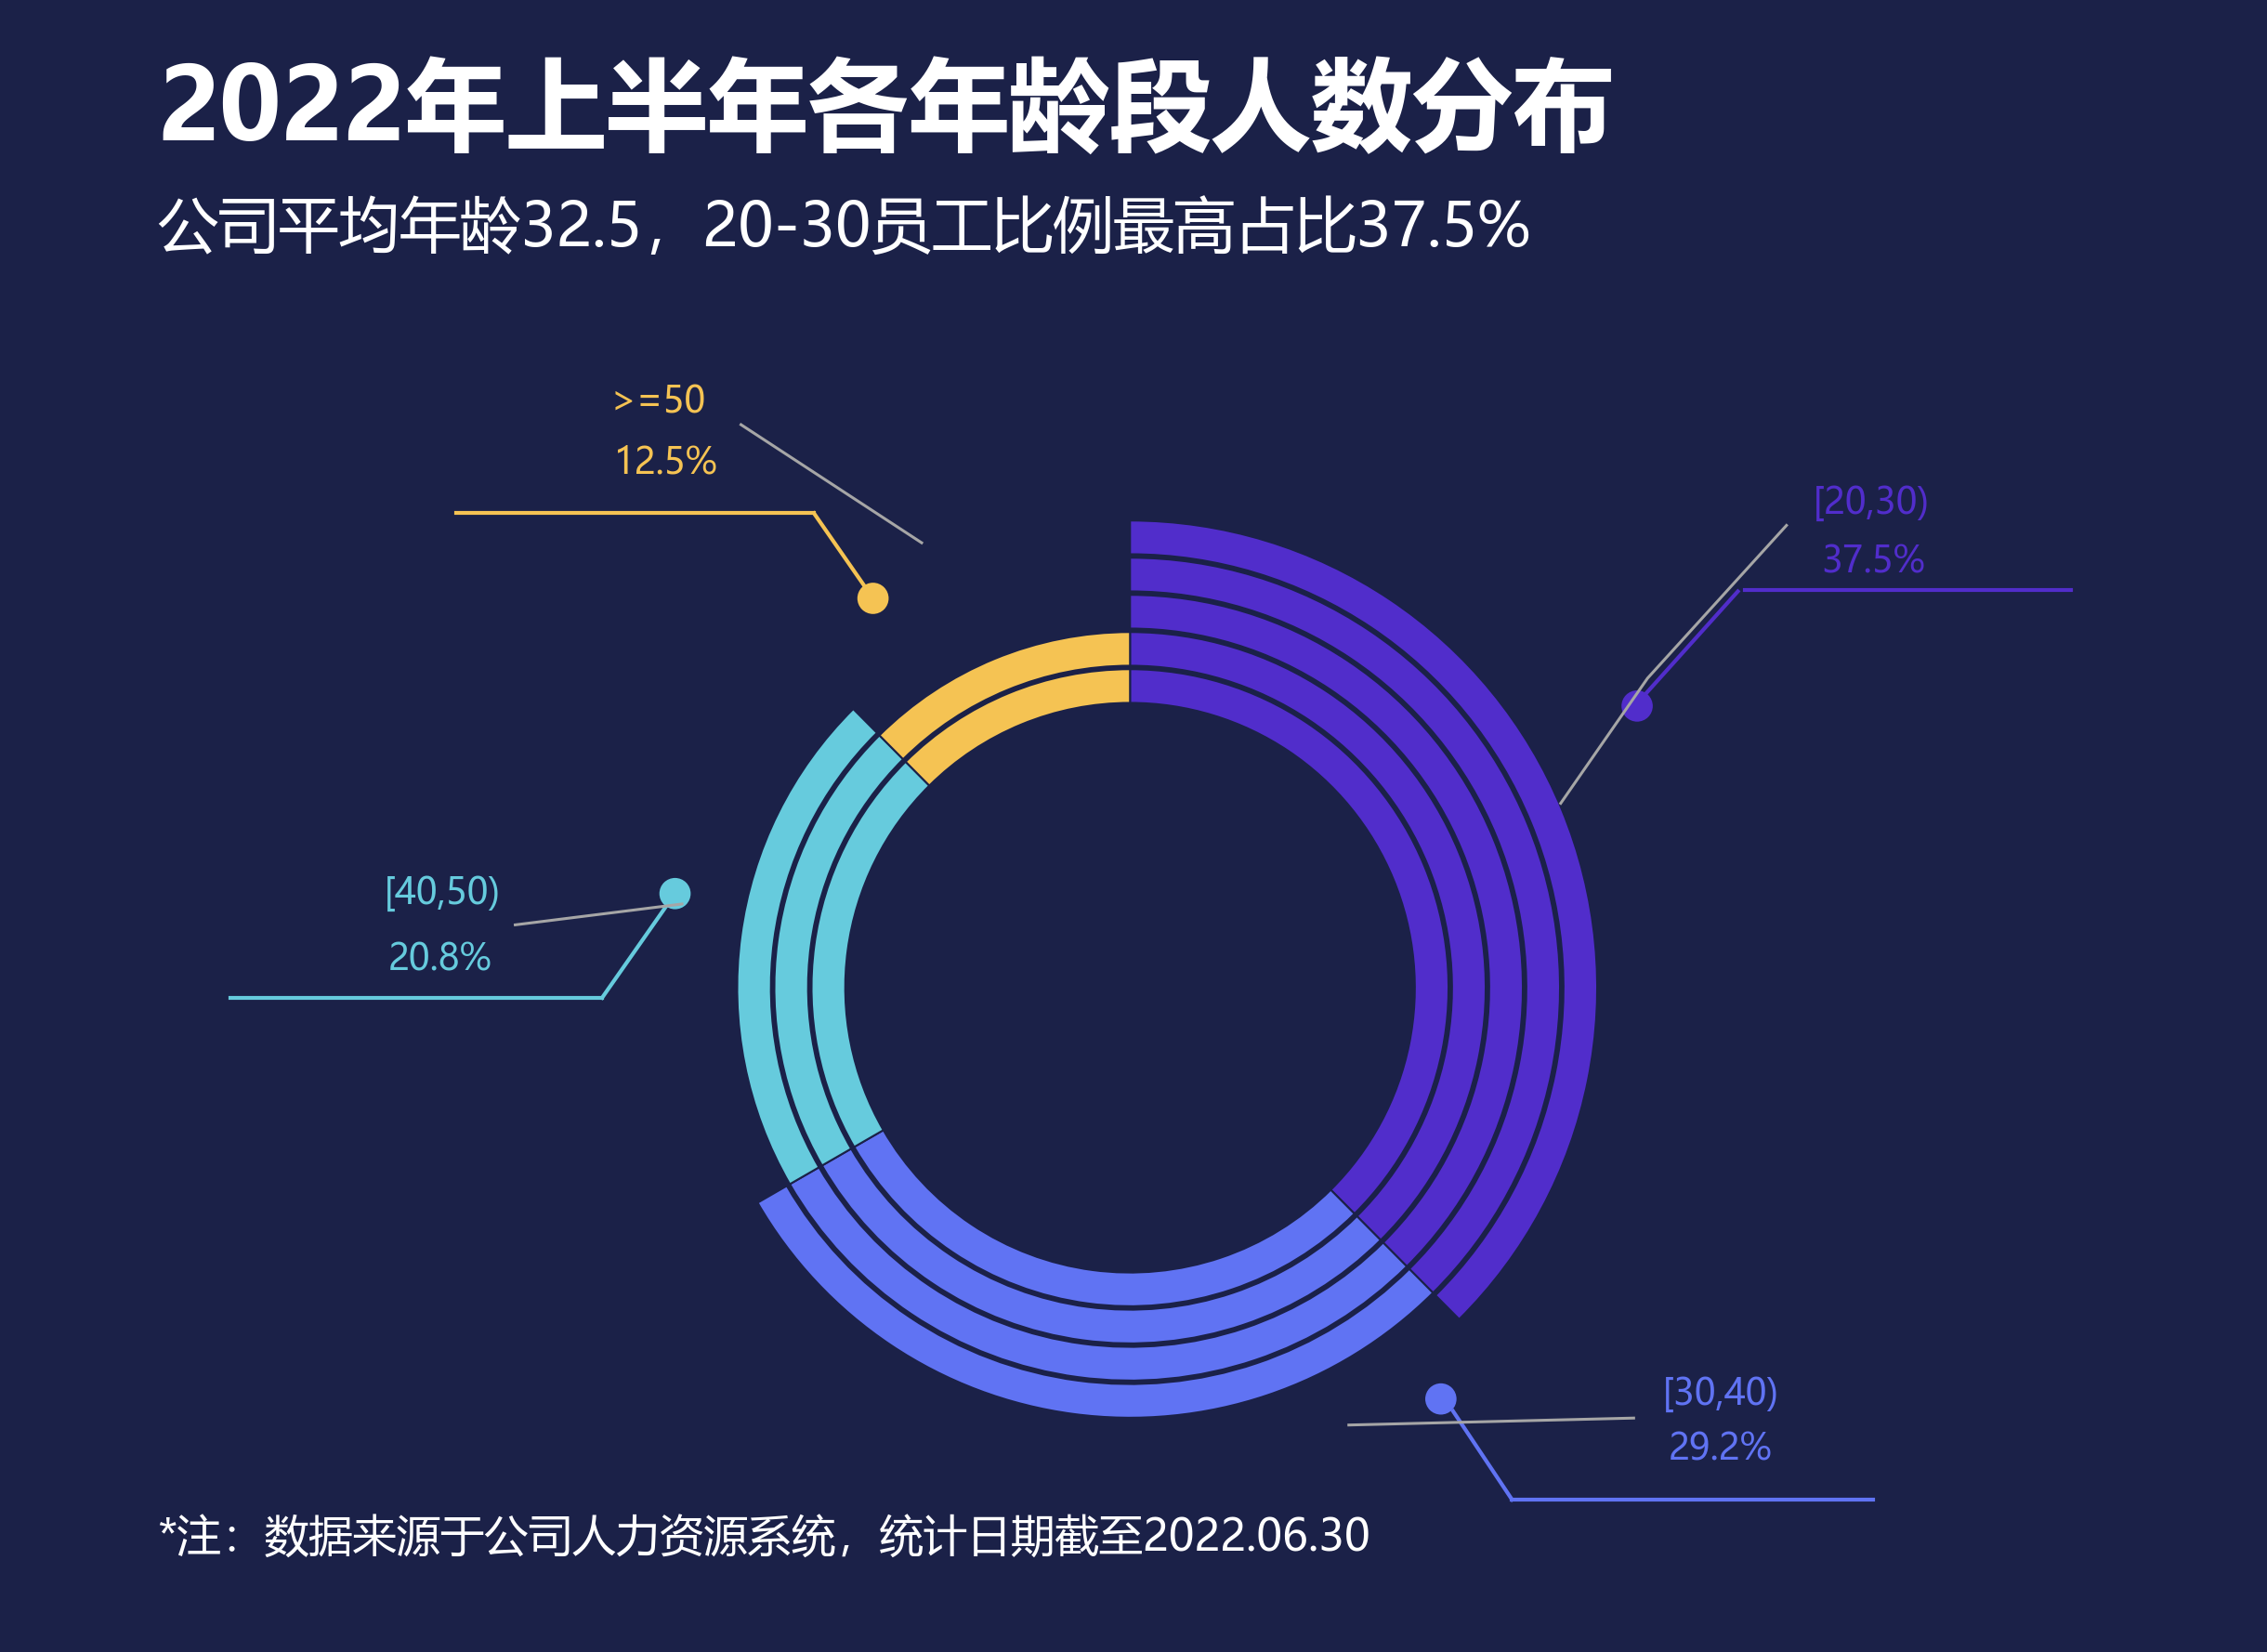

In [30]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Wedge, Circle

plt.rcParams["font.sans-serif"] = ["Microsoft YaHei"]
plt.rcParams["axes.unicode_minus"] = False

BG    = "#1b2148"
COL   = {"P": "#512DCB", "B": "#6073F3", "C": "#66CBDD", "Y": "#F5C353"}
GRAY  = "#A6A6A6"
WHITE = "#FFFFFF"

fig = plt.figure(figsize=(12, 12 * 465 / 642), dpi=200)
fig.patch.set_facecolor(BG)
ax = fig.add_axes([0, 0, 1, 1])
ax.set_xlim(0, 642)
ax.set_ylim(465, 0)
ax.axis("off")

CX, CY = 320.0, 279.1
BOUNDS = [0, 135.2, 240.0, 315.2, 360]
LAYERS = [(82.0, 91.7, 4), (92.7, 102.4, 4), (103.4, 113.1, 3),
          (114.1, 123.8, 2), (124.8, 134.5, 1)]
KEYS = ["P", "B", "C", "Y"]
for r0, r1, ncat in LAYERS:
    for j in range(ncat):
        b0, b1 = BOUNDS[j], BOUNDS[j + 1]
        ax.add_patch(Wedge((CX, CY), r1, b0 - 90, b1 - 90, width=r1 - r0,
                           facecolor=COL[KEYS[j]], edgecolor=BG, lw=0.75, zorder=2))

FS_LAB = 14
def callout(lines, ul, diag, dot, gray, key):
    c = COL[key]
    ax.plot([ul[0], ul[1]], [ul[2], ul[2]], color=c, lw=1.5, zorder=3)
    ax.plot([diag[0][0], diag[1][0]], [diag[0][1], diag[1][1]],
            color=c, lw=1.5, zorder=3)
    ax.add_patch(Circle(dot, 4.5, facecolor=c, edgecolor="none", zorder=3))
    if gray:
        ax.plot([p[0] for p in gray], [p[1] for p in gray],
                color=GRAY, lw=1.1, zorder=3)
    for s, tx, ty in lines:
        ax.text(tx, ty, s, ha="center", va="center", fontsize=FS_LAB,
                color=c, zorder=4)

callout([("[20,30)", 533.5, 139.5), ("37.5%", 534, 156.5)],
        ul=(497, 591, 164.5), diag=((495, 165), (468, 195)), dot=(466, 198),
        gray=[(509, 146), (469, 190), (444, 226)], key="P")

callout([(">=50", 184, 110.5), ("12.5%", 186.5, 128)],
        ul=(126, 229, 142.5), diag=((229, 142.5), (246, 167)), dot=(246, 167),
        gray=[(208, 117), (260, 151)], key="Y")

callout([("[40,50)", 122, 252), ("20.8%", 121.5, 271)],
        ul=(61, 168, 282), diag=((168, 282), (189, 252)), dot=(189, 252),
        gray=[(143, 261), (191, 255)], key="C")

callout([("[30,40)", 490, 396), ("29.2%", 490, 412)],
        ul=(430, 534, 426.5), diag=((430, 426.5), (413, 401)), dot=(409.5, 397.5),
        gray=[(383, 405), (465, 403)], key="B")

ax.text(40, 27, "2022年上半年各年龄段人数分布", ha="left", va="center",
        fontsize=39, fontweight="bold", color=WHITE, zorder=4)
ax.text(40, 61, "公司平均年龄32.5，20-30员工比例最高占比37.5%", ha="left",
        va="center", fontsize=23.5, color=WHITE, zorder=4)
ax.text(40, 438, "*注：数据来源于公司人力资源系统，统计日期截至2022.06.30",
        ha="left", va="center", fontsize=17, color=WHITE, zorder=4)

plt.savefig("20 南丁格尔圆环图.png", facecolor=BG, dpi=200)

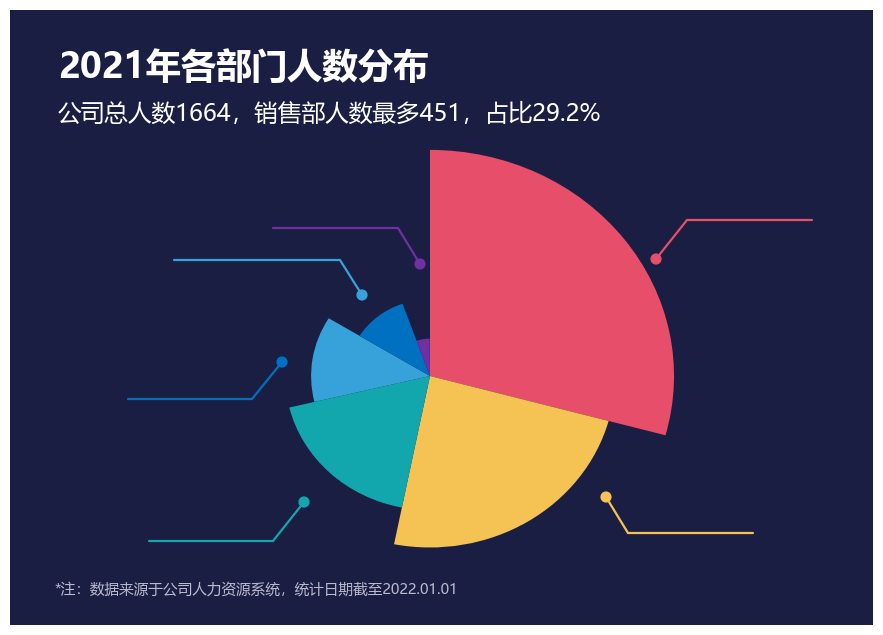

In [31]:
import math
import matplotlib
import matplotlib.pyplot as plt
from matplotlib import font_manager
from matplotlib.patches import Wedge, Rectangle, Circle

plt.rcParams["font.sans-serif"] = ["Microsoft YaHei"]
plt.rcParams["axes.unicode_minus"] = False

BG   = "#1A1E43"
RED  = "#E74E69"   
YEL  = "#F5C353"   
TEA  = "#11A7AD"   
BLU  = "#37A2DA"   
DBLU = "#0070C0"  
PUR  = "#7030A0"  
GREY = "#B9BAD0"

CW, CH = 863.0, 615.0
CX, CY = 420.0, 366.0          

sectors = [
    ("销售部", 29.20, RED,  -90.0,  15.2, 236.0),
    ("采购部", 22.70, YEL,   15.2, 101.2, 179.0),
    ("工程部", 17.50, TEA,  101.2, 166.4, 140.0),
    ("财务部", 13.60, BLU,  166.4, 211.6, 115.0),
    ("行政部", 10.30, DBLU, 211.6, 250.6,  80.0),
    ("人力部",  5.00, PUR,  250.6, 269.6,  39.0)]

leaders = {
    "销售部": ((646, 249), (677, 210), (802, 210)),
    "采购部": ((596, 487), (618, 523), (743, 523)),
    "工程部": ((294, 492), (263, 531), (139, 531)),
    "财务部": ((352, 285), (330, 250), (164, 250)),
    "行政部": ((272, 352), (242, 389), (118, 389)),
    "人力部": ((410, 254), (388, 218), (263, 218))}

fig = plt.figure(figsize=(CW / 100.0, CH / 100.0), dpi=100)
fig.patch.set_facecolor("white")
ax = fig.add_axes([0, 0, 1, 1])
ax.set_xlim(0, CW)
ax.set_ylim(CH, 0)            
ax.set_aspect("equal")
ax.axis("off")

ax.add_patch(Rectangle((0, 0), CW, CH, facecolor=BG, edgecolor="none"))

from matplotlib.transforms import Affine2D
ELL = (Affine2D().translate(-CX, -CY).scale(1.034, 0.958).translate(CX, CY)
       + ax.transData)
for name, pct, color, a1, a2, R in sectors:
    ax.add_patch(Wedge((CX, CY), R, a1, a2, facecolor=color,
                       edgecolor="none", linewidth=0, transform=ELL))

for name, pct, color, a1, a2, R in sectors:
    dot, elbow, end = leaders[name]
    ax.plot([dot[0], elbow[0], end[0]], [dot[1], elbow[1], end[1]],
            color=color, lw=1.6, solid_capstyle="round",
            solid_joinstyle="miter", zorder=5)
    ax.add_patch(Circle(dot, 5.6, facecolor=color, edgecolor="none", zorder=6))

ax.text(48, 58, "2021年各部门人数分布", color="white", fontsize=25.5,
        fontweight="bold", ha="left", va="center")
ax.text(48, 104, "公司总人数1664，销售部人数最多451，占比29.2%", color="white",
        fontsize=17, ha="left", va="center")
ax.text(44, 580, "*注：数据来源于公司人力资源系统，统计日期截至2022.01.01",
        color=GREY, fontsize=10.5, ha="left", va="center")

fig.savefig("21 南丁格尔（PPT）.png", facecolor="white")

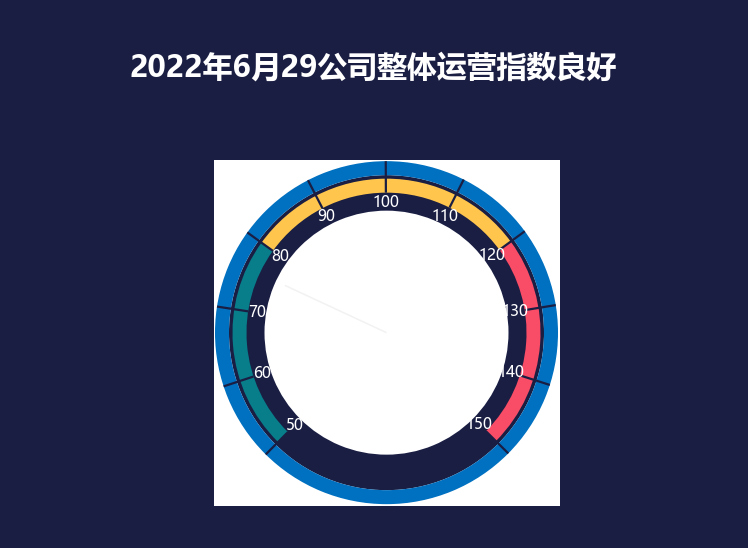

In [32]:
import math
import matplotlib.pyplot as plt
from matplotlib.patches import Wedge, Rectangle

plt.rcParams["font.sans-serif"] = ["Microsoft YaHei"]
plt.rcParams["axes.unicode_minus"] = False

BG     = "#1A1E43"   
BLUE   = "#0070C0"  
ORANGE = "#FFC54D"  
TEAL   = "#087E8B" 
RED    = "#F94C66"  
NEEDLE = "#F2F2F2"  

CW, CH = 728.0, 528.0                
TITLE_XY = (363.5, 58.5)               
PLOT = (204.0, 150.0, 346.0, 346.0)  
CX, CY = 376.5, 322.66           

R_DARK_IN, R_DARK_OUT = 122.0, 157.5   
R_VAL_IN,  R_VAL_OUT  = 140.0, 154.0   
R_RING_IN, R_RING_OUT = 157.5, 171.5 

V0, V1, VSTEP = 50.0, 150.0, 10.0    
A0, DPA = 134.75, 2.7            
BASE_ANGLE = 70.2                   
POINTER_VALUE = 76                   

ticks = [V0 + i * VSTEP for i in range(int((V1 - V0) / VSTEP) + 1)]
tick_ang = {v: A0 + (v - V0) * DPA for v in ticks}

bands = [(TEAL,   V0,    80.0),
         (ORANGE, 80.0, 120.0),
         (RED,    120.0, V1)]

fig = plt.figure(figsize=(CW / 100.0, CH / 100.0), dpi=100)
fig.patch.set_facecolor(BG)
ax = fig.add_axes([0, 0, 1, 1])
ax.set_xlim(0, CW)
ax.set_ylim(CH, 0)                     
ax.set_aspect("equal")
ax.axis("off")

ax.add_patch(Rectangle((0, 0), CW, CH, facecolor=BG,
                       edgecolor="none", zorder=0))
ax.add_patch(Rectangle((PLOT[0], PLOT[1]), PLOT[2], PLOT[3],
                       facecolor="white", edgecolor="none", zorder=1))

ax.add_patch(Wedge((CX, CY), R_DARK_OUT, 0, 360,
                   width=R_DARK_OUT - R_DARK_IN,
                   facecolor=BG, edgecolor="none", zorder=2))

for color, va, vb in bands:
    ax.add_patch(Wedge((CX, CY), R_VAL_OUT, tick_ang[va], tick_ang[vb],
                       width=R_VAL_OUT - R_VAL_IN,
                       facecolor=color, edgecolor="none", zorder=3))

ax.add_patch(Wedge((CX, CY), R_RING_OUT, 0, 360,
                   width=R_RING_OUT - R_RING_IN,
                   facecolor=BLUE, edgecolor="none", zorder=4))

for v in ticks:
    a = math.radians(tick_ang[v])
    x1, y1 = CX + R_VAL_IN * math.cos(a), CY + R_VAL_IN * math.sin(a)
    x2, y2 = CX + R_RING_OUT * math.cos(a), CY + R_RING_OUT * math.sin(a)
    ax.plot([x1, x2], [y1, y2], color=BG, lw=1.6,
            solid_capstyle="butt", zorder=5)

R_LABEL = 130.5
for v in ticks:
    a = math.radians(tick_ang[v])
    x, y = CX + R_LABEL * math.cos(a), CY + R_LABEL * math.sin(a)
    ax.text(x, y, "%d" % v, color="white", fontsize=11.0,
            ha="center", va="center", zorder=7)

pt_ang = math.radians(A0 + BASE_ANGLE)
x1, y1 = CX, CY
x2, y2 = CX + 112.0 * math.cos(pt_ang), CY + 112.0 * math.sin(pt_ang)
ax.plot([x1, x2], [y1, y2], color=NEEDLE, lw=1.1,
        solid_capstyle="butt", zorder=6)

ax.text(TITLE_XY[0], TITLE_XY[1], "2022年6月29公司整体运营指数良好",
        color="white", fontsize=21.5, fontweight="bold",
        ha="center", va="center", zorder=8)

fig.savefig("22 仪表盘图.png", facecolor=BG, dpi=200)

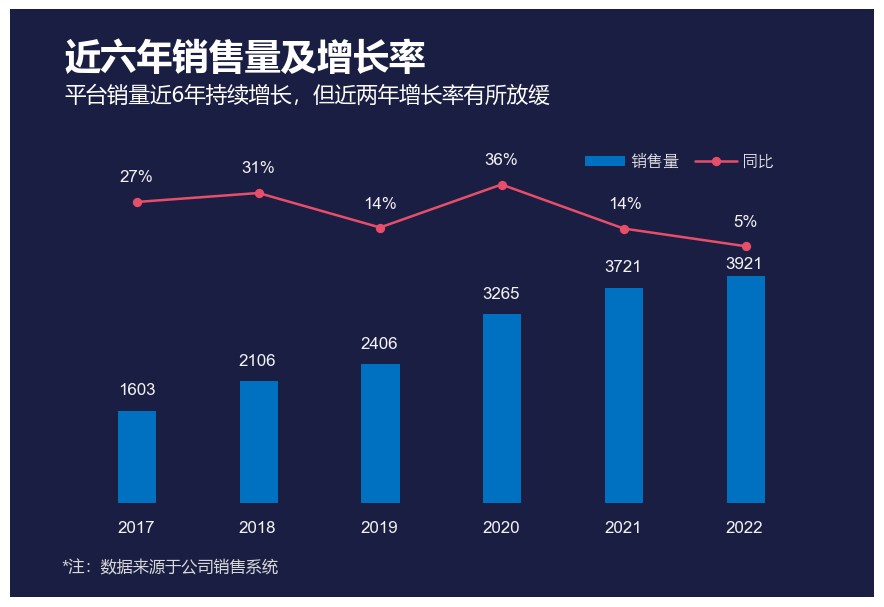

In [33]:
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

CARD_X, CARD_Y, CARD_W, CARD_H = 442, 23, 864, 588
FIG_W, FIG_H = CARD_W / 100, CARD_H / 100

BG      = "#1A1E43"   
BAR     = "#0070C0"  
LINE    = "#E74E69"   
WHITE   = "#FFFFFF"   
TXT     = "#F2F2F2"  
GREY    = "#D9D9D9"  

CJK       = "Microsoft YaHei"     
CJK_BOLD  = "Microsoft YaHei"    
LEG_FONT  = "DengXian"             
NUM       = "Arial"             

FS_TITLE, FS_SUB = 26, 15.5
FS_NUM = 12.2
FS_LEGEND, FS_NOTE = 11.8, 11.6

TXT_DY = 0.4
TTL_DY = 1.0      
SUB_DY = 1.0
NOTE_DY = 0.5
LEG_DY = 0.6

BAR_W      = 38
BAR_BOTTOM = 517.0

BARS = [
    (550, 38, 425, "1603", 568.5, 403.5),
    (672, 38, 395, "2106", 689.5, 374.5),
    (793, 39, 378, "2406", 811.5, 357.5),
    (915, 38, 328, "3265", 933.5, 307.5),
    (1037, 38, 302, "3721", 1055.0, 280.5),
    (1159, 38, 290, "3921", 1176.5, 277.5)]

LINE_PTS = [
    (568.5, 216.0, 568.0, 190.5, "27%"),
    (690.5, 207.0, 690.0, 181.5, "31%"),
    (812.0, 241.5, 812.0, 217.5, "14%"),
    (933.5, 198.5, 933.0, 173.5, "36%"),
    (1055.5, 242.5, 1057.0, 217.5, "14%"),
    (1177.5, 260.2, 1177.5, 235.5, "5%")]

YEARS = [("2017", 568.5), ("2018", 689.5), ("2019", 811.5),
         ("2020", 933.5), ("2021", 1055.0), ("2022", 1176.5)]
YEAR_CY = 541.5

LEG_SWATCH = (1017, 170, 40, 10)   
LEG_TXT1   = (1062, 174.5, "销售量")
LEG_LINE   = (1127, 1169, 175.0)     
LEG_DOT    = (1147.5, 175.0)
LEG_TXT2   = (1173, 175.0, "同比")

TITLE    = (496, 71.0,  "近六年销售量及增长率")
SUBTITLE = (496, 108.0, "平台销量近6年持续增长，但近两年增长率有所放缓")
NOTE     = (493, 580.0, "*注：数据来源于公司销售系统")

fig = plt.figure(figsize=(FIG_W, FIG_H), dpi=100)
ax = fig.add_axes([0, 0, 1, 1])
ax.set_xlim(CARD_X, CARD_X + CARD_W)
ax.set_ylim(CARD_Y + CARD_H, CARD_Y)    
ax.set_aspect("equal")
ax.axis("off")

ax.add_patch(Rectangle((CARD_X, CARD_Y), CARD_W, CARD_H,
                       facecolor=BG, edgecolor="none", zorder=0))

for x0, w, top, _, _, _ in BARS:
    ax.add_patch(Rectangle((x0, top), w, BAR_BOTTOM - top,
                           facecolor=BAR, edgecolor="none", zorder=2))

xs = [p[0] for p in LINE_PTS]
ys = [p[1] for p in LINE_PTS]
ax.plot(xs, ys, color=LINE, lw=1.8, solid_capstyle="round",
        solid_joinstyle="round", zorder=3)
ax.plot(xs, ys, linestyle="none", marker="o", markersize=5.7,
        markerfacecolor=LINE, markeredgecolor=LINE, zorder=4)

for _, _, _, val, cx, cy in BARS:
    ax.text(cx, cy + TXT_DY, val, color=TXT, fontsize=FS_NUM, fontfamily=NUM,
            ha="center", va="center", zorder=6)

for _, _, cx, cy, txt in LINE_PTS:
    ax.text(cx, cy + TXT_DY, txt, color=TXT, fontsize=FS_NUM, fontfamily=NUM,
            ha="center", va="center", zorder=6)

for txt, cx in YEARS:
    ax.text(cx, YEAR_CY + TXT_DY, txt, color=TXT, fontsize=FS_NUM,
            fontfamily=NUM, ha="center", va="center", zorder=6)

sx, sy, sw, sh = LEG_SWATCH
ax.add_patch(Rectangle((sx, sy), sw, sh, facecolor=BAR, edgecolor="none",
                       zorder=5))
tx, ty, tt = LEG_TXT1
ax.text(tx, ty + LEG_DY, tt, color=TXT, fontsize=FS_LEGEND, fontfamily=LEG_FONT,
        ha="left", va="center", zorder=6)

lx0, lx1, ly = LEG_LINE
ax.plot([lx0, lx1], [ly, ly], color=LINE, lw=1.8,
        solid_capstyle="round", zorder=5)
ax.plot([LEG_DOT[0]], [LEG_DOT[1]], linestyle="none", marker="o",
        markersize=5.7, markerfacecolor=LINE, markeredgecolor=LINE, zorder=6)
tx2, ty2, tt2 = LEG_TXT2
ax.text(tx2, ty2 + LEG_DY, tt2, color=TXT, fontsize=FS_LEGEND,
        fontfamily=LEG_FONT, ha="left", va="center", zorder=6)

ax.text(TITLE[0], TITLE[1] + TTL_DY, TITLE[2], color=WHITE, fontsize=FS_TITLE,
        fontfamily=CJK_BOLD, fontweight="bold", ha="left", va="center", zorder=6)
ax.text(SUBTITLE[0], SUBTITLE[1] + SUB_DY, SUBTITLE[2], color=WHITE,
        fontsize=FS_SUB, fontfamily=CJK, ha="left", va="center", zorder=6)
ax.text(NOTE[0], NOTE[1] + NOTE_DY, NOTE[2], color=GREY, fontsize=FS_NOTE,
        fontfamily=CJK, ha="left", va="center", zorder=6)

fig.savefig("23 柱形折线图.png", dpi=100)

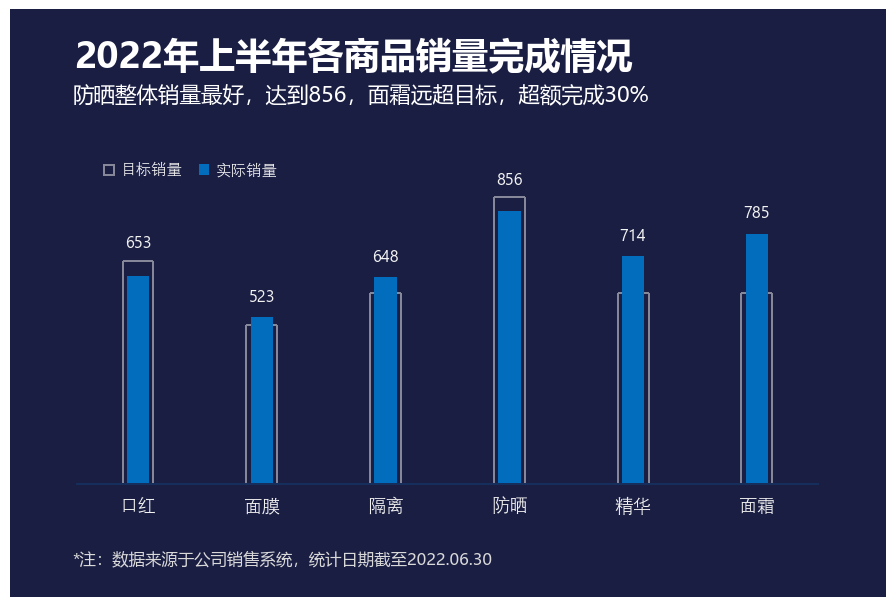

In [34]:
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from matplotlib.lines import Line2D

CW, CH = 876, 588                 
FIG_W, FIG_H = CW / 100, CH / 100

BG     = "#1A1E43"      
BAR    = "#016DBC"     
FRAME  = "#86889A"      
AXIS   = "#152E5C"      
WHITE  = "#FFFFFF"      
TXT    = "#F2F2F2"     
GREY   = "#D9D9D9"      

DATA = [
    ("口红",    653, 700),
    ("面膜",    523, 500),
    ("隔离",    648, 600),
    ("防晒",    856, 900),
    ("精华",    714, 600),
    ("面霜",    785, 600)]
TITLE    = "2022年上半年各商品销量完成情况"
SUBTITLE = "防晒整体销量最好，达到856，面霜远超目标，超额完成30%"
NOTE     = "*注：数据来源于公司销售系统，统计日期截至2022.06.30"

BASE_Y   = 474.0                           
AXIS_X0, AXIS_X1 = 66.0, 809.0         

BARS = [
    (113, 143, 117, 139),
    (236, 267, 241, 263),
    (360, 391, 364, 387),
    (484, 515, 488, 511),
    (608, 639, 612, 634),
    (731, 762, 736, 758)]

TARGET_TOP = [252, 316, 284, 188, 284, 284]
ACTUAL_TOP = [267, 308, 268, 202, 247, 225]

LBL_CX = [128.0, 252.0, 375.5, 499.5, 623.0, 747.0]
LBL_CY = [232.5, 286.0, 246.0, 169.0, 225.0, 202.0]

CAT_CY = 496.0

LEG_FRAME = (94, 156, 10, 10)
LEG_FILL  = (189, 155, 10, 11)
LEG_T1    = (111, 159, "目标销量")  
LEG_T2    = (206, 159, "实际销量")

TITLE_POS = (64.0, 46.0)
SUB_POS   = (63.0, 84.0)
NOTE_POS  = (62.0, 549.0)

CJK_BOLD = "Microsoft YaHei"
CJK      = "Microsoft YaHei"
LINE_F   = "DengXian"
NUM      = "Segoe UI"

FS_TITLE, FS_SUB = 26.0, 15.5
FS_NUM, FS_LEG   = 11.8, 11.2
FS_CAT, FS_NOTE  = 13.3, 11.8

TTL_DY  = 2.0
SUB_DY  = 1.2
NOTE_DY = 1.3
LEG_DY  = 1.0
CAT_DY  = 0.5
NUM_DY  = 1.5

LW2 = 2.0 * 72 / 100.0 

fig = plt.figure(figsize=(FIG_W, FIG_H), dpi=100)
ax = fig.add_axes([0, 0, 1, 1])
ax.set_xlim(0, CW)
ax.set_ylim(CH, 0)
ax.set_aspect("equal")
ax.axis("off")

ax.add_patch(Rectangle((0, 0), CW, CH, facecolor=BG, edgecolor="none", zorder=0))

for i, (xl, xr, _, _) in enumerate(BARS):
    top = TARGET_TOP[i]
    ax.add_line(Line2D([xl, xl], [top, BASE_Y], color=FRAME, lw=LW2,
                       solid_capstyle="butt", zorder=3))
    ax.add_line(Line2D([xr, xr], [top, BASE_Y], color=FRAME, lw=LW2,
                       solid_capstyle="butt", zorder=3))
    ax.add_line(Line2D([xl, xr], [top, top], color=FRAME, lw=LW2,
                       solid_capstyle="butt", zorder=3))

for i, (_, _, xa, xb) in enumerate(BARS):
    top = ACTUAL_TOP[i]
    ax.add_patch(Rectangle((xa, top), xb - xa, BASE_Y - top,
                           facecolor=BAR, edgecolor="none", zorder=4))

ax.add_patch(Rectangle((AXIS_X0, BASE_Y), AXIS_X1 - AXIS_X0, 2,
                       facecolor=AXIS, edgecolor="none", zorder=5))

for i, (_, act, _) in enumerate(DATA):
    ax.text(LBL_CX[i], LBL_CY[i] + NUM_DY, str(act), color=TXT,
            fontsize=FS_NUM, fontfamily=NUM, ha="center", va="center", zorder=6)

for i, (name, _, _) in enumerate(DATA):
    ax.text(LBL_CX[i], CAT_CY + CAT_DY, name, color=TXT,
            fontsize=FS_CAT, fontfamily=LINE_F, ha="center", va="center", zorder=6)

fx, fy, fw, fh = LEG_FRAME
ax.add_patch(Rectangle((fx, fy), fw, fh, facecolor="none", edgecolor=FRAME,
                       linewidth=LW2, zorder=5))
bx, by, bw, bh = LEG_FILL
ax.add_patch(Rectangle((bx, by), bw, bh, facecolor=BAR, edgecolor="none", zorder=5))
for tx, ty, s in (LEG_T1, LEG_T2):
    ax.text(tx, ty + LEG_DY, s, color=TXT, fontsize=FS_LEG, fontfamily=LINE_F,
            ha="left", va="center", zorder=6)

ax.text(TITLE_POS[0], TITLE_POS[1] + TTL_DY, TITLE, color=WHITE,
        fontsize=FS_TITLE, fontfamily=CJK_BOLD, fontweight="bold",
        ha="left", va="center", zorder=6)
ax.text(SUB_POS[0], SUB_POS[1] + SUB_DY, SUBTITLE, color=WHITE,
        fontsize=FS_SUB, fontfamily=CJK, ha="left", va="center", zorder=6)
ax.text(NOTE_POS[0], NOTE_POS[1] + NOTE_DY, NOTE, color=GREY,
        fontsize=FS_NOTE, fontfamily=CJK, ha="left", va="center", zorder=6)

fig.savefig("24 目标柱形图.png", dpi=100)

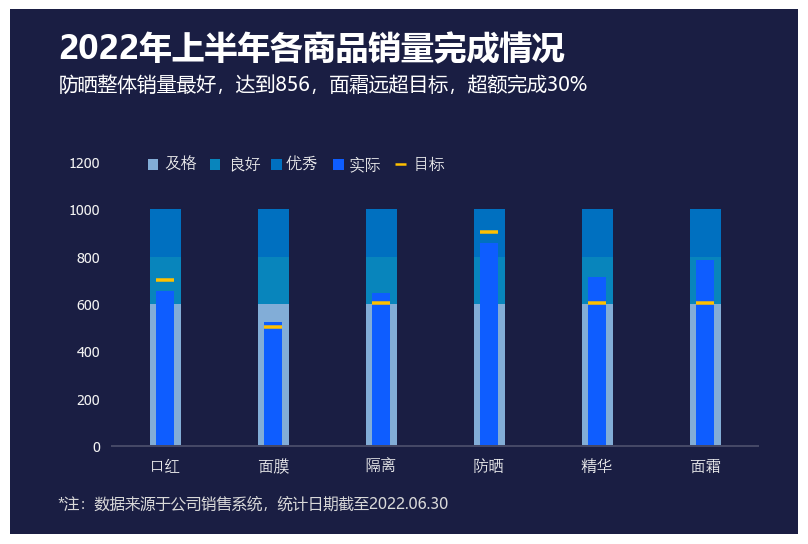

In [35]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from matplotlib.lines import Line2D
import numpy as np

CW, CH = 788, 525
FIG_W, FIG_H = CW / 100, CH / 100

BG       = "#1A1E43"   
C_PASS   = "#82ADD7"  
C_GOOD   = "#0885BC"   
C_EXCEL  = "#0070C0"  
C_ACT    = "#0E5DFF"   
C_GOAL   = "#FFC000"   
C_AXIS   = "#454866"   
WHITE    = "#FFFFFF"   
TXT      = "#F2F2F2"   
GREY     = "#D9D9D9"   

DATA = [
    ("口红", 600, 200, 200, 653, 700),
    ("面膜", 600, 200, 200, 523, 500),
    ("隔离", 600, 200, 200, 648, 600),
    ("防晒", 600, 200, 200, 856, 900),
    ("精华", 600, 200, 200, 714, 600),
    ("面霜", 600, 200, 200, 785, 600)]

Y0    = 436.5           
K     = 0.2366667    
AXIS_X0, AXIS_X1 = 101, 749
AXIS_Y, AXIS_H = 436, 2


def yv(v):
    return Y0 - K * v

BAR0_X   = 140            
BAR_STEP = 108      
WIDE_W   = 31            
NARROW_W = 18          
NARROW_DX = 6      

STACK_TOP = 200
GOOD_TOP  = 248
PASS_TOP  = 295

ACTUAL_TOP = [282, 313, 284, 234, 268, 251]

LEG_SWATCH = [("pass", 138, 150, 10, 11), ("good", 200, 150, 10, 11),
              ("excel", 261, 150, 11, 11), ("act", 323, 150, 11, 11)]
LEG_GOAL_LINE = (385.2, 395.7, 155.44)
LEG_TXT = [(155, "及格"), (219, "良好"), (277, "优秀"), (340, "实际"), (404, "目标")]
LEG_CY = 154.3

TITLE    = (50.0, 39.0, "2022年上半年各商品销量完成情况")
SUBTITLE = (50.0, 73.5, "防晒整体销量最好，达到856，面霜远超目标，超额完成30%")
NOTE     = (49.0, 492.5, "*注：数据来源于公司销售系统，统计日期截至2022.06.30")
CAT_CY   = 456.4
YAXIS_CX = 89.0

P = dict(
    ttl_fs=23.6, ttl_dx=-2.0, ttl_dy=1.8,
    sub_fs=14.2, sub_dx=-1.0, sub_dy=1.5,
    note_fs=11.0, note_dx=-2.0, note_dy=1.2,
    leg_fs=11.8, leg_dx=-1.0, leg_dy=0.9,
    cat_fs=11.6, cat_dx=-0.5, cat_dy=0.9,
    yax_fs=10.4, yax_dx=1.0, yax_dy=1.5)

FONT_TTL = "Microsoft YaHei"
FONT_SUB = "Microsoft YaHei"
FONT_LEG = "DengXian"
FONT_CAT = "DengXian"
FONT_NUM = "Tahoma"

fig = plt.figure(figsize=(FIG_W, FIG_H), dpi=100)
ax = fig.add_axes([0, 0, 1, 1])
ax.set_xlim(0, CW)
ax.set_ylim(CH, 0)
ax.set_aspect("equal")
ax.axis("off")

ax.add_patch(Rectangle((0, 0), CW, CH, facecolor=BG, edgecolor="none", zorder=0))

for i, (name, ps, gd, ex, act, goal) in enumerate(DATA):
    x0 = BAR0_X + BAR_STEP * i
    ax.add_patch(Rectangle((x0, PASS_TOP), WIDE_W, AXIS_Y - PASS_TOP,
                           facecolor=C_PASS, edgecolor="none", zorder=2))
    ax.add_patch(Rectangle((x0, GOOD_TOP), WIDE_W, PASS_TOP - GOOD_TOP,
                           facecolor=C_GOOD, edgecolor="none", zorder=2))
    ax.add_patch(Rectangle((x0, STACK_TOP), WIDE_W, GOOD_TOP - STACK_TOP,
                           facecolor=C_EXCEL, edgecolor="none", zorder=2))
    top = ACTUAL_TOP[i]
    ax.add_patch(Rectangle((x0 + NARROW_DX, top), NARROW_W, AXIS_Y - top,
                           facecolor=C_ACT, edgecolor="none", zorder=4))

ax.add_patch(Rectangle((AXIS_X0, AXIS_Y), AXIS_X1 - AXIS_X0, AXIS_H,
                       facecolor=C_AXIS, edgecolor="none", zorder=5))

for i, (name, ps, gd, ex, act, goal) in enumerate(DATA):
    xc = BAR0_X + BAR_STEP * i + NARROW_DX
    y = yv(goal)
    ax.add_line(Line2D([xc, xc + NARROW_W], [y, y], color=C_GOAL,
                       lw=3.5 * 72 / 100, solid_capstyle="butt", zorder=6))

for v in (1200, 1000, 800, 600, 400, 200, 0):
    ax.text(YAXIS_CX + P["yax_dx"], yv(v) + P["yax_dy"], str(v), color=TXT,
            fontsize=P["yax_fs"], fontfamily=FONT_NUM,
            ha="right", va="center", zorder=7)

for i, (name, *_rest) in enumerate(DATA):
    cx = BAR0_X + BAR_STEP * i + WIDE_W / 2.0
    ax.text(cx + P["cat_dx"], CAT_CY + P["cat_dy"], name, color=TXT,
            fontsize=P["cat_fs"], fontfamily=FONT_CAT,
            ha="center", va="center", zorder=7)

swatch_color = {"pass": C_PASS, "good": C_GOOD, "excel": C_EXCEL, "act": C_ACT}
for key, sx, sy, sw, sh in LEG_SWATCH:
    ax.add_patch(Rectangle((sx, sy), sw, sh, facecolor=swatch_color[key],
                           edgecolor="none", zorder=7))
gx0, gx1, gy = LEG_GOAL_LINE
ax.add_line(Line2D([gx0, gx1], [gy, gy], color=C_GOAL,
                   lw=2.5 * 72 / 100, solid_capstyle="butt", zorder=7))
for tx, t in LEG_TXT:
    ax.text(tx + P["leg_dx"], LEG_CY + P["leg_dy"], t, color=TXT,
            fontsize=P["leg_fs"], fontfamily=FONT_LEG,
            ha="left", va="center", zorder=7)

ax.text(TITLE[0] + P["ttl_dx"], TITLE[1] + P["ttl_dy"], TITLE[2], color=WHITE,
        fontsize=P["ttl_fs"], fontfamily=FONT_TTL, fontweight="bold",
        ha="left", va="center", zorder=7)
ax.text(SUBTITLE[0] + P["sub_dx"], SUBTITLE[1] + P["sub_dy"], SUBTITLE[2],
        color=WHITE, fontsize=P["sub_fs"], fontfamily=FONT_SUB,
        ha="left", va="center", zorder=7)
ax.text(NOTE[0] + P["note_dx"], NOTE[1] + P["note_dy"], NOTE[2], color=GREY,
        fontsize=P["note_fs"], fontfamily=FONT_SUB,
        ha="left", va="center", zorder=7)

fig.savefig("25 子弹图.png", facecolor=BG, dpi=200)

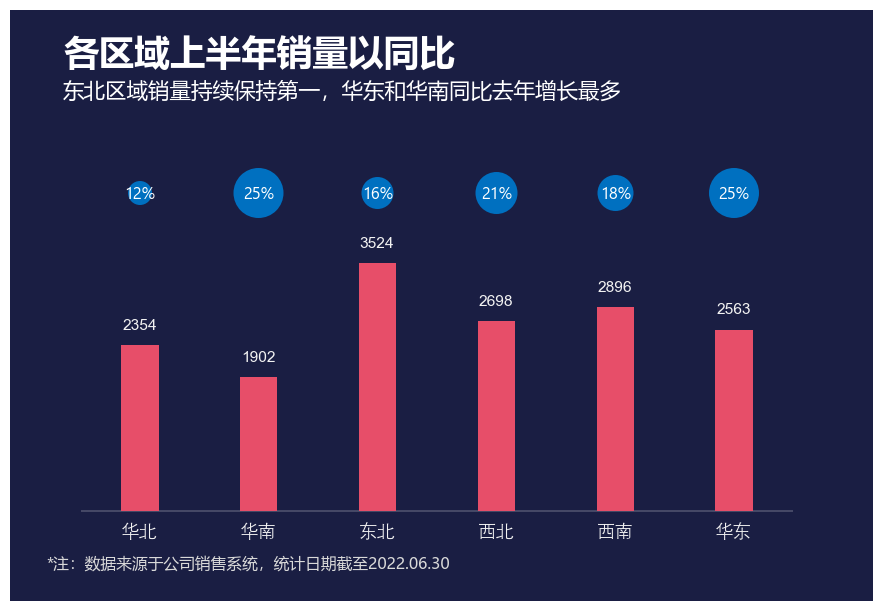

In [36]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, Circle

CARD_X0, CARD_Y0, CARD_W, CARD_H = 535, 13, 863, 591
BG      = "#1A1E43"
BAR_C   = "#E74E69"
DOT_C   = "#0070C0"
AXIS_C  = "#454866"
TEXT_C  = "#FFFFFF"
LABEL_C = "#F2F2F2"
NOTE_C  = "#D9D9D9"

DATA = [
    ("华北", 2354, 12),
    ("华南", 1902, 25),
    ("东北", 3524, 16),
    ("西北", 2698, 21),
    ("西南", 2896, 18),
    ("华东", 2563, 25)]

BAR_LEFT  = [646, 765, 884, 1003, 1122, 1240]
BAR_RIGHT = [683, 801, 920, 1039, 1158, 1277]
BASE_ROW  = 513
PX_PER_VALUE = 1.0 / 14.19
DOT_CY    = 196.0

AXIS_X0, AXIS_X1 = 606, 1317
AXIS_Y0, AXIS_Y1 = 513, 514

TITLE    = "各区域上半年销量以同比"
SUBTITLE = "东北区域销量持续保持第一，华东和华南同比去年增长最多"
NOTE     = "*注：数据来源于公司销售系统，统计日期截至2022.06.30"

TITLE_POS = (589, 56)
SUB_POS   = (589, 94)
NOTE_POS  = (572, 566)

TITLE_STYLE = dict(fontsize=25.7, fontweight="bold", fontfamily="Microsoft YaHei",
                   color=TEXT_C, ha="left", va="center")
SUB_STYLE   = dict(fontsize=15.5, fontweight="normal", fontfamily="Microsoft YaHei",
                   color=TEXT_C, ha="left", va="center")
NOTE_STYLE  = dict(fontsize=11.35, fontweight="normal", fontfamily="Microsoft YaHei",
                   color=NOTE_C, ha="left", va="center")
PCT_STYLE   = dict(fontsize=11.8, fontweight="normal", fontfamily="Segoe UI",
                   color=TEXT_C, ha="center", va="center")
VAL_STYLE   = dict(fontsize=11.2, fontweight="normal", fontfamily="Arial",
                   color=LABEL_C, ha="center", va="bottom")
CAT_STYLE   = dict(fontsize=13.3, fontweight="normal", fontfamily="DengXian",
                   color=LABEL_C, ha="center", va="center")

TITLE_OFF = (-1.0, 2.5)
SUB_OFF   = (-1.0, 1.0)
NOTE_OFF  = (-1.0, 1.5)
PCT_OFF   = (0.0, 1.5)
VAL_OFF   = (-0.5, 4.0)
CAT_OFF   = (-0.5, 0.5)

fig = plt.figure(figsize=(CARD_W / 100.0, CARD_H / 100.0), dpi=100)
ax = fig.add_axes([0, 0, 1, 1])
ax.set_xlim(CARD_X0, CARD_X0 + CARD_W)
ax.set_ylim(CARD_Y0 + CARD_H, CARD_Y0)
ax.set_aspect("equal")
ax.axis("off")

ax.add_patch(Rectangle((CARD_X0, CARD_Y0), CARD_W, CARD_H,
                       facecolor=BG, edgecolor="none", zorder=0))

ax.add_patch(Rectangle((AXIS_X0, AXIS_Y0), AXIS_X1 - AXIS_X0 + 1,
                       AXIS_Y1 - AXIS_Y0 + 1, facecolor=AXIS_C,
                       edgecolor="none", zorder=1))

for x0, x1, (name, val, pct) in zip(BAR_LEFT, BAR_RIGHT, DATA):
    h = int(round(val * PX_PER_VALUE))
    top = BASE_ROW - h + 1
    ax.add_patch(Rectangle((x0, top), x1 - x0 + 1, BASE_ROW - top + 1,
                           facecolor=BAR_C, edgecolor="none", zorder=2))

for x0, x1, (name, val, pct) in zip(BAR_LEFT, BAR_RIGHT, DATA):
    cx = (x0 + x1 + 1) / 2.0
    ax.add_patch(Circle((cx, DOT_CY), pct, facecolor=DOT_C,
                        edgecolor="none", zorder=3))
    ax.text(cx + PCT_OFF[0], DOT_CY + PCT_OFF[1], "%d%%" % pct,
            zorder=4, **PCT_STYLE)

for x0, x1, (name, val, pct) in zip(BAR_LEFT, BAR_RIGHT, DATA):
    cx = (x0 + x1 + 1) / 2.0
    h = int(round(val * PX_PER_VALUE))
    top = BASE_ROW - h + 1
    ax.text(cx + VAL_OFF[0], top - 16.5 + VAL_OFF[1], str(val),
            zorder=4, **VAL_STYLE)

for x0, x1, (name, val, pct) in zip(BAR_LEFT, BAR_RIGHT, DATA):
    cx = (x0 + x1 + 1) / 2.0
    ax.text(cx + CAT_OFF[0], 535 + CAT_OFF[1], name, zorder=4, **CAT_STYLE)

ax.text(TITLE_POS[0] + TITLE_OFF[0], TITLE_POS[1] + TITLE_OFF[1],
        TITLE, zorder=4, **TITLE_STYLE)
ax.text(SUB_POS[0] + SUB_OFF[0], SUB_POS[1] + SUB_OFF[1],
        SUBTITLE, zorder=4, **SUB_STYLE)
ax.text(NOTE_POS[0] + NOTE_OFF[0], NOTE_POS[1] + NOTE_OFF[1],
        NOTE, zorder=4, **NOTE_STYLE)

fig.savefig("26 柱形图.png", facecolor=BG, dpi=200)

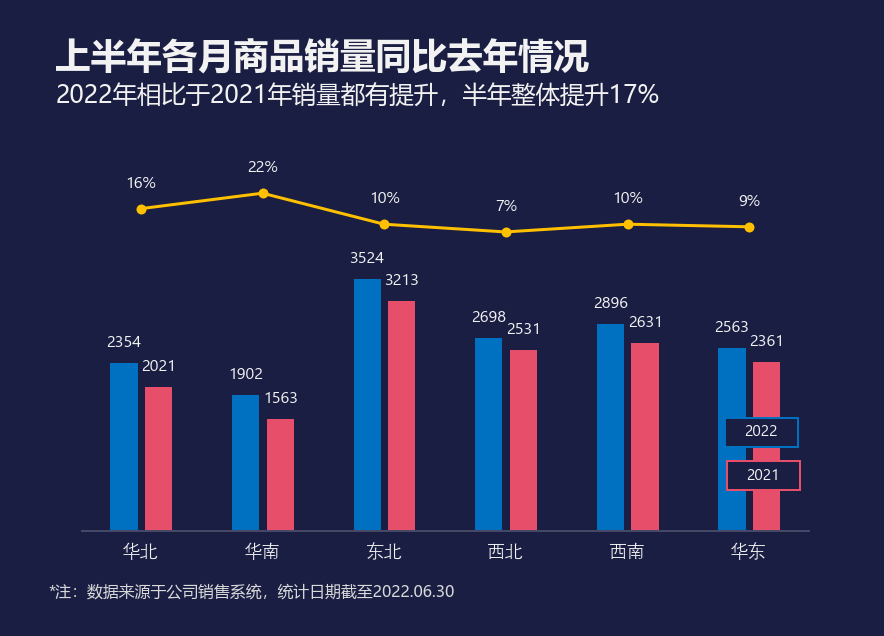

In [37]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from matplotlib.lines import Line2D

CARD_X0, CARD_Y0, CARD_W, CARD_H = 541, 16, 864, 616
BG     = "#1A1E43"
BLUE   = "#0070C0"
PINK   = "#E74E69"
YELLOW = "#FFC000"
AXIS   = "#454866"
TXT    = "#F2F2F2"
NOTEC  = "#D9D9D9"

CATS = ["华北", "华南", "东北", "西北", "西南", "华东"]
V22  = [2354, 1902, 3524, 2698, 2896, 2563]
V21  = [2021, 1563, 3213, 2531, 2631, 2361]
PCT  = [16, 22, 10, 7, 10, 9]

BX0 = [641, 763, 885, 1006, 1128, 1249]
BX1 = [668, 789, 911, 1032, 1154, 1276]
PX0 = [676, 798, 919, 1041, 1162, 1284]
PX1 = [702, 824, 945, 1067, 1189, 1310]

BASE = 536
YC   = 537.24
YS   = 0.07158263
MC   = 255.8333
MS   = 2.58333
AX0, AX1, AXH = 612, 1340, 2

LBX, LBY, LBW, LBH = 1256, 424, 73, 29
LPX, LPY, LPW, LPH = 1258, 467, 73, 29

TITLE = "上半年各月商品销量同比去年情况"
SUB   = "2022年相比于2021年销量都有提升，半年整体提升17%"
NOTE  = "*注：数据来源于公司销售系统，统计日期截至2022.06.30"
LEG1  = "2022"
LEG2  = "2021"

Q = dict(
    ttl_ff="Microsoft YaHei", ttl_fs=25.62, ttl_fw="bold", ttl_dx=-1.0, ttl_dy=2.5,
    sub_ff="Microsoft YaHei", sub_fs=17.58, sub_fw="normal", sub_dx=-1.0, sub_dy=2.0,
    pct_ff="Segoe UI", pct_fs=11.76, pct_fw="normal", pct_dx=0.4, pct_dy=2.0,
    val_ff="Segoe UI", val_fs=11.66, val_fw="normal", val_dx=0.4, val_dy=2.2,
    cat_ff="DengXian", cat_fs=13.3, cat_fw="normal", cat_dx=0.4, cat_dy=0.5,
    note_ff="Microsoft YaHei", note_fs=11.4, note_fw="normal", note_dx=-0.8, note_dy=1.5,
    leg_ff="Segoe UI", leg_fs=11.2, leg_fw="normal", leg_dx=-0.2, leg_dy=2.0,
    ln_lw=3.0, mk_sz=10.0, bar_dx=0.0, bar_dy=0.0, ln_dy=0.2, ax_dy=0.0,)

def bar_top(v):
    return int(round(YC - YS * v))

fig = plt.figure(figsize=(CARD_W / 100.0, CARD_H / 100.0), dpi=100)
ax = fig.add_axes([0, 0, 1, 1])
ax.set_xlim(CARD_X0, CARD_X0 + CARD_W)
ax.set_ylim(CARD_Y0 + CARD_H, CARD_Y0)
ax.set_aspect("equal")
ax.axis("off")
fig.patch.set_facecolor(BG)
ax.set_facecolor(BG)

bdx, bdy = Q["bar_dx"], Q["bar_dy"]

for i in range(6):
    tb = bar_top(V22[i])
    tp = bar_top(V21[i])
    ax.add_patch(Rectangle((BX0[i] + bdx, tb + bdy), BX1[i] - BX0[i] + 1,
                           BASE - tb, facecolor=BLUE, edgecolor="none", zorder=2))
    ax.add_patch(Rectangle((PX0[i] + bdx, tp + bdy), PX1[i] - PX0[i] + 1,
                           BASE - tp, facecolor=PINK, edgecolor="none", zorder=2))

ax.add_patch(Rectangle((AX0, BASE + Q["ax_dy"]), AX1 - AX0 + 1, AXH,
                       facecolor=AXIS, edgecolor="none", zorder=3))

xs = [(BX0[i] + PX1[i]) / 2.0 for i in range(6)]
ys = [MC - MS * PCT[i] + Q["ln_dy"] for i in range(6)]
ax.add_line(Line2D(xs, ys, color=YELLOW, lw=Q["ln_lw"] * 72 / 100.0,
                   solid_capstyle="round", zorder=4))
ax.plot(xs, ys, "o", color=YELLOW, ms=Q["mk_sz"] * 72 / 100.0,
        markeredgewidth=0, zorder=5)

ax.add_patch(Rectangle((LBX, LBY), LBW, LBH, facecolor=BG, edgecolor=BLUE,
                       lw=2 * 72 / 100.0, zorder=6))
ax.add_patch(Rectangle((LPX, LPY), LPW, LPH, facecolor=BG, edgecolor=PINK,
                       lw=2 * 72 / 100.0, zorder=6))

ax.text(587 + Q["ttl_dx"], 62 + Q["ttl_dy"], TITLE, color=TXT, ha="left",
        va="center", fontsize=Q["ttl_fs"], fontfamily=Q["ttl_ff"],
        fontweight=Q["ttl_fw"], zorder=7)
ax.text(588 + Q["sub_dx"], 101 + Q["sub_dy"], SUB, color=TXT, ha="left",
        va="center", fontsize=Q["sub_fs"], fontfamily=Q["sub_ff"],
        fontweight=Q["sub_fw"], zorder=7)

for i in range(6):
    ax.text(xs[i] + Q["pct_dx"], MC - MS * PCT[i] - 27 + Q["pct_dy"],
            "%d%%" % PCT[i], color=TXT, ha="center", va="center",
            fontsize=Q["pct_fs"], fontfamily=Q["pct_ff"],
            fontweight=Q["pct_fw"], zorder=7)

for i in range(6):
    ax.text(xs[i] - 17.5 + Q["val_dx"], bar_top(V22[i]) - 22.5 + Q["val_dy"],
            str(V22[i]), color=TXT, ha="center", va="center",
            fontsize=Q["val_fs"], fontfamily=Q["val_ff"],
            fontweight=Q["val_fw"], zorder=7)
    ax.text(xs[i] + 17.5 + Q["val_dx"], bar_top(V21[i]) - 22.5 + Q["val_dy"],
            str(V21[i]), color=TXT, ha="center", va="center",
            fontsize=Q["val_fs"], fontfamily=Q["val_ff"],
            fontweight=Q["val_fw"], zorder=7)

for i in range(6):
    ax.text(xs[i] + Q["cat_dx"], 558 + Q["cat_dy"], CATS[i], color=TXT,
            ha="center", va="center", fontsize=Q["cat_fs"],
            fontfamily=Q["cat_ff"], fontweight=Q["cat_fw"], zorder=7)

ax.text(580 + Q["note_dx"], 597 + Q["note_dy"], NOTE, color=NOTEC, ha="left",
        va="center", fontsize=Q["note_fs"], fontfamily=Q["note_ff"],
        fontweight=Q["note_fw"], zorder=7)

ax.text(LBX + LBW / 2.0 + Q["leg_dx"], LBY + LBH / 2.0 - 1.5 + Q["leg_dy"],
        LEG1, color=TXT, ha="center", va="center", fontsize=Q["leg_fs"],
        fontfamily=Q["leg_ff"], fontweight=Q["leg_fw"], zorder=7)
ax.text(LPX + LPW / 2.0 + Q["leg_dx"], LPY + LPH / 2.0 - 1.5 + Q["leg_dy"],
        LEG2, color=TXT, ha="center", va="center", fontsize=Q["leg_fs"],
        fontfamily=Q["leg_ff"], fontweight=Q["leg_fw"], zorder=7)

fig.savefig("27 簇状柱形折线图.png", dpi=200, facecolor=BG)

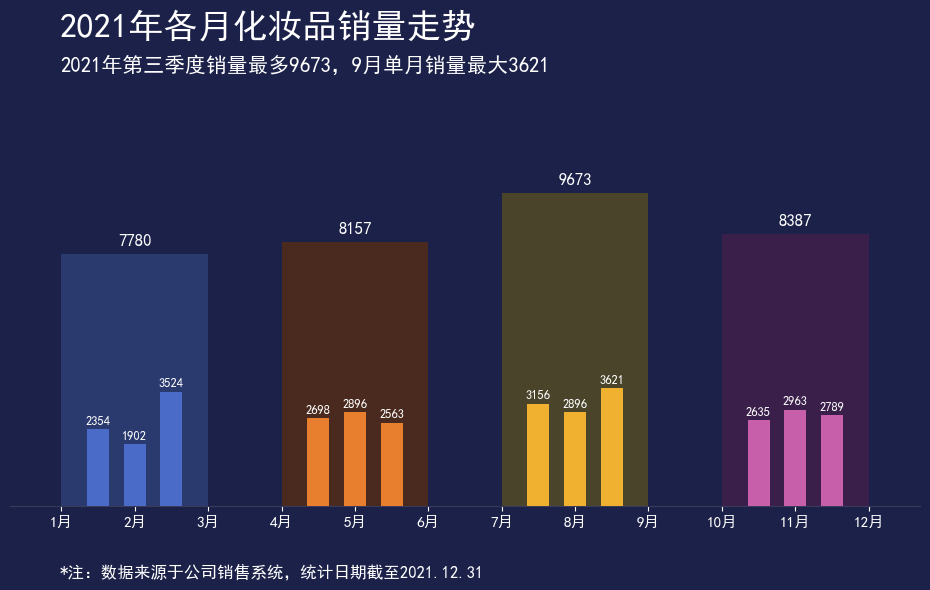

In [3]:
import matplotlib.pyplot as plt

plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei']
plt.rcParams['axes.unicode_minus'] = False

BG   = '#1b2148'
TEXT = '#ffffff'

months = ['1月','2月','3月','4月','5月','6月',
          '7月','8月','9月','10月','11月','12月']
month_vals = [2354, 1902, 3524, 2698, 2896, 2563,
              3156, 2896, 3621, 2635, 2963, 2789]
quarter_vals = [7780, 8157, 9673, 8387]

quarter_colors = [
    ('#2A3A6E', '#4A6BC8'),
    ('#4A2A1E', '#E87F2F'),
    ('#4A442A', '#F0B030'),
    ('#3A1F4A', '#C85FAA'),
]

fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor(BG); ax.set_facecolor(BG)
fig.subplots_adjust(left=0.05, right=0.96, top=0.76, bottom=0.14)

for sp in ['top', 'right', 'left']:
    ax.spines[sp].set_visible(False)
ax.spines['bottom'].set_color('#3A3A5A')
ax.set_yticks([])
ax.tick_params(axis='x', colors=TEXT, labelsize=12)
ax.set_axisbelow(True)

Q_WIDTH = 2.0
M_WIDTH = 0.3
M_GAP   = 0.50 

for q in range(4):
    dark, bright = quarter_colors[q]
    q_center = q * 3 + 1
    q_val    = quarter_vals[q]

    ax.bar(q_center, q_val, width=Q_WIDTH, color=dark, zorder=2)

    ax.text(q_center, q_val + 200, str(q_val),
            ha='center', va='bottom',
            fontsize=12, color=TEXT)

    for m, offset in enumerate([-M_GAP, 0, +M_GAP]):
        x_pos = q_center + offset
        m_val = month_vals[q * 3 + m]
        ax.bar(x_pos, m_val, width=M_WIDTH,
               color=bright, zorder=3)
        ax.text(x_pos, m_val + 80, str(m_val),
                ha='center', va='bottom',
                fontsize=9, color=TEXT)

ax.set_xticks(range(12))
ax.set_xticklabels(months, fontsize=11)
ax.set_xlim(-0.7, 11.7)
ax.set_ylim(0, 11500)

fig.text(0.1, 0.94, '2021年各月化妆品销量走势',
         ha='left', va='center', fontsize=25, fontweight='bold', color=TEXT)
fig.text(0.1, 0.875, '2021年第三季度销量最多9673，9月单月销量最大3621',
         ha='left', va='center', fontsize=15, color=TEXT)
fig.text(0.1, 0.03, '*注：数据来源于公司销售系统，统计日期截至2021.12.31',
         ha='left', va='center', fontsize=12, color=TEXT)

plt.savefig('28 复合柱形图.png', facecolor=BG, dpi=200)

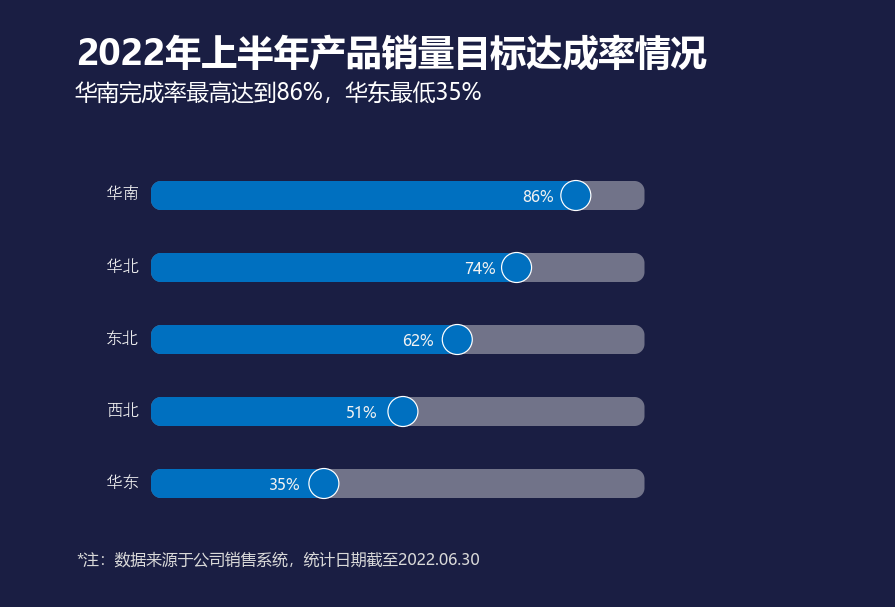

In [38]:
import matplotlib.pyplot as plt
import numpy as np

CARD_X, CARD_Y, CARD_W, CARD_H = 547, 21, 876, 588
BG = "#1A1E43"
TRACK = "#717389"
FILL = "#0070C0"
WHITE = "#FFFFFF"
LIGHT = "#F2F2F2"
GREY = "#D9D9D9"

TITLE = "2022年上半年产品销量目标达成率情况"
SUBTITLE = "华南完成率最高达到86%，华东最低35%"
NOTE = "*注：数据来源于公司销售系统，统计日期截至2022.06.30"

DATA = [("华南", 86), ("华北", 74), ("东北", 62), ("西北", 51), ("华东", 35)]
PCT_NUDGE = [1.2, 2.9, 0.2, -2.4, -0.4]

DEF = dict(
    track_l=688.0, track_r=1181.5, bar_h=29.0, bar_r=10.0,
    row0=207.5, row_step=72.0, val_l=688.0, val_w=494.0,
    mark_r=15.0, mark_lw=1.2 * 72.0 / 100.0, mark_dy=0.0,
    ttl_x=614.0, ttl_y=64.5, ttl_ff="Microsoft YaHei", ttl_fs=26.06, ttl_fw="bold", ttl_dx=-1.0, ttl_dy=1.75,
    sub_x=613.0, sub_y=102.5, sub_ff="Microsoft YaHei", sub_fs=16.16, sub_fw="normal", sub_dx=-1.0, sub_dy=1.0,
    pct_gap=24.0, pct_ff="Microsoft YaHei", pct_fs=11.05, pct_fw="normal", pct_dx=0.6, pct_dy=1.5,
    cat_x=676.0, cat_ff="DengXian", cat_fs=11.94, cat_fw="normal", cat_dx=0.0, cat_dy=-0.75,
    note_x=614.0, note_y=570.5, note_ff="Microsoft YaHei", note_fs=11.35, note_fw="normal", note_dx=-1.0, note_dy=1.0,
)


def rounded(x0, y0, w, h, r, n=40):
    t = np.linspace(0.0, np.pi / 2.0, n)
    cx1, cy1 = x0 + w - r, y0 + r
    cx2, cy2 = x0 + w - r, y0 + h - r
    cx3, cy3 = x0 + r, y0 + h - r
    cx4, cy4 = x0 + r, y0 + r
    xs = [x0 + r, cx1]
    ys = [y0, y0]
    xs.extend(list(cx1 + r * np.sin(t)))
    ys.extend(list(cy1 - r * np.cos(t)))
    xs.extend([x0 + w, x0 + w])
    ys.extend([cy1, cy2])
    xs.extend(list(cx2 + r * np.cos(t)))
    ys.extend(list(cy2 + r * np.sin(t)))
    xs.extend([cx2, cx3])
    ys.extend([y0 + h, y0 + h])
    xs.extend(list(cx3 - r * np.sin(t)))
    ys.extend(list(cy3 + r * np.cos(t)))
    xs.extend([x0, x0])
    ys.extend([cy3, cy4])
    xs.extend(list(cx4 - r * np.cos(t)))
    ys.extend(list(cy4 - r * np.sin(t)))
    xs.append(x0 + r)
    ys.append(y0)
    return np.asarray(xs), np.asarray(ys)


p = DEF
l, r = p["track_l"], p["track_r"]
tw = r - l
vl, vw = p["val_l"], p["val_w"]
rows = [(n, v, p["row0"] + i * p["row_step"]) for i, (n, v) in enumerate(DATA)]

fig = plt.figure(figsize=(CARD_W / 100.0, CARD_H / 100.0), dpi=100)
ax = fig.add_axes([0, 0, 1, 1])
ax.set_xlim(CARD_X, CARD_X + CARD_W)
ax.set_ylim(CARD_Y + CARD_H, CARD_Y)
ax.set_aspect("equal")
ax.axis("off")
fig.patch.set_facecolor(BG)
ax.set_facecolor(BG)

top = lambda cy: cy - p["bar_h"] / 2.0

for name, val, cy in rows:
    xs, ys = rounded(l, top(cy), tw, p["bar_h"], p["bar_r"])
    ax.add_patch(plt.Polygon(np.c_[xs, ys], closed=True, facecolor=TRACK, edgecolor="none", zorder=2))

for name, val, cy in rows:
    w = vw * val / 100.0
    xs, ys = rounded(vl, top(cy), w, p["bar_h"], p["bar_r"])
    ax.add_patch(plt.Polygon(np.c_[xs, ys], closed=True, facecolor=FILL, edgecolor="none", zorder=3))

for name, val, cy in rows:
    cx = vl + vw * val / 100.0
    ax.add_patch(plt.Circle((cx, cy + p["mark_dy"]), p["mark_r"], facecolor=FILL, edgecolor=WHITE,
                            linewidth=p["mark_lw"], zorder=5))

ax.text(p["ttl_x"] + p["ttl_dx"], p["ttl_y"] + p["ttl_dy"], TITLE, color=WHITE, fontsize=p["ttl_fs"],
        fontfamily=p["ttl_ff"], fontweight=p["ttl_fw"], ha="left", va="center", zorder=6)
ax.text(p["sub_x"] + p["sub_dx"], p["sub_y"] + p["sub_dy"], SUBTITLE, color=WHITE, fontsize=p["sub_fs"],
        fontfamily=p["sub_ff"], fontweight=p["sub_fw"], ha="left", va="center", zorder=6)
ax.text(p["note_x"] + p["note_dx"], p["note_y"] + p["note_dy"], NOTE, color=GREY, fontsize=p["note_fs"],
        fontfamily=p["note_ff"], fontweight=p["note_fw"], ha="left", va="center", zorder=6)

for name, val, cy in rows:
    ax.text(p["cat_x"] + p["cat_dx"], cy + p["cat_dy"], name, color=LIGHT, fontsize=p["cat_fs"],
            fontfamily=p["cat_ff"], fontweight=p["cat_fw"], ha="right", va="center", zorder=6)

for i, (name, val, cy) in enumerate(rows):
    cx = vl + vw * val / 100.0
    ax.text(cx - p["pct_gap"] + p["pct_dx"] + PCT_NUDGE[i], cy + p["pct_dy"], "%d%%" % val, color=LIGHT,
            fontsize=p["pct_fs"], fontfamily=p["pct_ff"], fontweight=p["pct_fw"],
            ha="right", va="center", zorder=6)

fig.savefig("29 滑珠图.png", dpi=200, facecolor=BG)

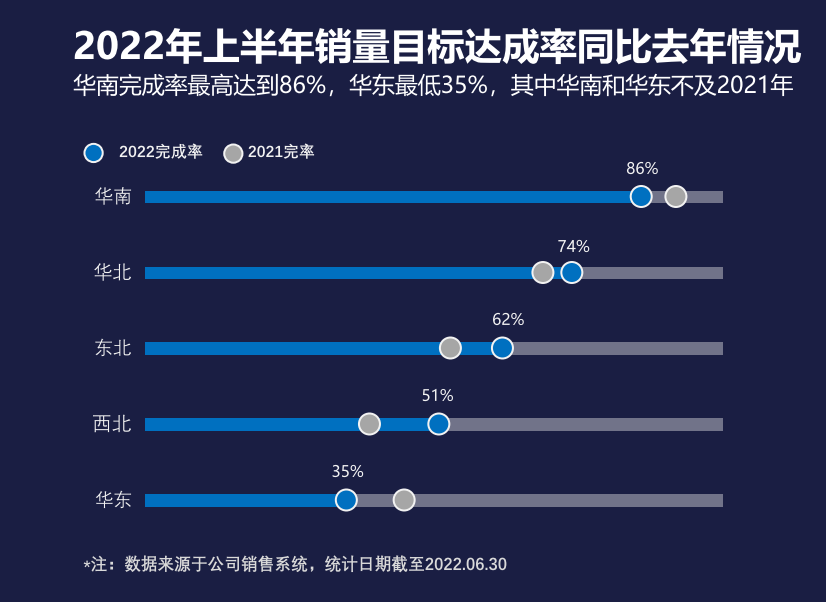

In [40]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import PathPatch, Rectangle, Circle
from matplotlib.textpath import TextPath
from matplotlib.font_manager import FontProperties
from matplotlib.transforms import Affine2D

CARD_W, CARD_H = 806, 583
BG = "#1A1E43"
TRACK = "#717389"
FILL = "#0070C0"
DOT2 = "#A6A6A6"
WHITE = "#FFFFFF"
LIGHT = "#F2F2F2"
NOTE_C = "#D9D9D9"

TITLE = "2022年上半年销量目标达成率同比去年情况"
SUBTITLE = "华南完成率最高达到86%，华东最低35%，其中华南和华东不及2021年"
NOTE = "*注：数据来源于公司销售系统，统计日期截至2022.06.30"
LEG1 = "2022完成率"
LEG2 = "2021完率"

DATA = [("华南", 86, 92), ("华北", 74, 69), ("东北", 62, 53), ("西北", 51, 39), ("华东", 35, 45)]

p = dict(
    track_l=135.0, track_r=713.0,
    val_l=133.9545, val_w=5.782103,
    row_top=[182.0, 258.0, 333.0, 409.0, 485.0],
    row_h=[12.0, 12.0, 13.0, 13.0, 13.0],
    mark_r=10.5, mark_lw=2.0 * 72.0 / 100.0, mark_dy=-0.5,
    leg_r=9.12, leg_lw=2.0 * 72.0 / 100.0,
    leg_bx=83.58, leg_by=143.97, leg_gx=223.33, leg_gy=144.62,
    ttl_ff="Microsoft YaHei", ttl_fw="bold", ttl_box=(64.75, 790.12, 19.06, 54.34),
    sub_ff="Microsoft YaHei", sub_fw="normal", sub_box=(63.62, 781.94, 64.59, 86.19),
    note_ff="DengXian", note_fw="bold", note_box=(73.72, 495.38, 546.31, 562.41),
    leg_ff="DengXian", leg_fw="bold",
    leg1_box=(109.78, 191.22, 134.39, 148.76), leg2_box=(238.62, 303.08, 134.39, 148.70),
    pct_y=-29.5, pct_h=12.25, pct_ff="Microsoft YaHei", pct_fw="normal", pct_dx=0.38, pct_dy=0.0,
    cat_x=121.05, cat_dy=-1.07, cat_h=17.52, cat_ff="DengXian", cat_fw="normal", cat_dx=0.0)

PCT_NUDGE = [0.8, 1.6, 5.6, -1.3, 1.2]
PCT_NUDGE_Y = [0.5, 2.5, 0.0, 0.0, 0.0]


def ink_text(ax, s, ff, fw, box, color, zorder=6):
    x0, x1, y0, y1 = box
    tp = TextPath((0.0, 0.0), s, size=100.0, prop=FontProperties(family=ff, weight=fw))
    bb = tp.get_extents()
    sx = (x1 - x0 + 1.0) / bb.width
    sy = (y1 - y0 + 1.0) / bb.height
    tr = Affine2D().translate(-bb.x0, -bb.y1).scale(sx, -sy).translate(x0, y0)
    ax.add_patch(PathPatch(tr.transform_path(tp), facecolor=color, edgecolor="none", zorder=zorder))


def ink_at(ax, s, ff, fw, x, cy, h, color, right=False, zorder=6):
    tp = TextPath((0.0, 0.0), s, size=100.0, prop=FontProperties(family=ff, weight=fw))
    bb = tp.get_extents()
    k = h / bb.height
    cx = (x - bb.width * k / 2.0) if right else x
    tr = Affine2D().translate(-(bb.x0 + bb.x1) / 2.0, -(bb.y0 + bb.y1) / 2.0).scale(k, -k).translate(cx, cy)
    ax.add_patch(PathPatch(tr.transform_path(tp), facecolor=color, edgecolor="none", zorder=zorder))


vl, vw = p["val_l"], p["val_w"]
tops = list(p["row_top"])
hts = list(p["row_h"])

fig = plt.figure(figsize=(CARD_W / 100.0, CARD_H / 100.0), dpi=100)
ax = fig.add_axes([0, 0, 1, 1])
ax.set_xlim(0, CARD_W)
ax.set_ylim(CARD_H, 0)
ax.set_aspect("equal")
ax.axis("off")
fig.patch.set_facecolor(BG)
ax.set_facecolor(BG)

for i in range(len(DATA)):
    ax.add_patch(Rectangle((p["track_l"], tops[i]), p["track_r"] - p["track_l"], hts[i],
                           facecolor=TRACK, edgecolor="none", zorder=2))

for i, (name, v22, v21) in enumerate(DATA):
    xe = vl + vw * v22
    ax.add_patch(Rectangle((p["track_l"], tops[i]), xe - p["track_l"], hts[i],
                           facecolor=FILL, edgecolor="none", zorder=3))

for i, (name, v22, v21) in enumerate(DATA):
    cy = tops[i] + hts[i] / 2.0 + p["mark_dy"]
    ax.add_patch(Circle((vl + vw * v21, cy), p["mark_r"], facecolor=DOT2,
                        edgecolor=LIGHT, linewidth=p["mark_lw"], zorder=5))
    ax.add_patch(Circle((vl + vw * v22, cy), p["mark_r"], facecolor=FILL,
                        edgecolor=LIGHT, linewidth=p["mark_lw"], zorder=5))

ax.add_patch(Circle((p["leg_bx"], p["leg_by"]), p["leg_r"], facecolor=FILL,
                    edgecolor=LIGHT, linewidth=p["leg_lw"], zorder=5))
ax.add_patch(Circle((p["leg_gx"], p["leg_gy"]), p["leg_r"], facecolor=DOT2,
                    edgecolor=LIGHT, linewidth=p["leg_lw"], zorder=5))

ink_text(ax, TITLE, p["ttl_ff"], p["ttl_fw"], p["ttl_box"], WHITE)
ink_text(ax, SUBTITLE, p["sub_ff"], p["sub_fw"], p["sub_box"], WHITE)
ink_text(ax, NOTE, p["note_ff"], p["note_fw"], p["note_box"], NOTE_C)
ink_text(ax, LEG1, p["leg_ff"], p["leg_fw"], p["leg1_box"], LIGHT)
ink_text(ax, LEG2, p["leg_ff"], p["leg_fw"], p["leg2_box"], LIGHT)

for i, (name, v22, v21) in enumerate(DATA):
    cy = tops[i] + hts[i] / 2.0
    ink_at(ax, name, p["cat_ff"], p["cat_fw"], p["cat_x"] + p["cat_dx"], cy + p["cat_dy"],
           p["cat_h"], LIGHT, right=True)
    ink_at(ax, "%d%%" % v22, p["pct_ff"], p["pct_fw"],
           vl + vw * v22 + PCT_NUDGE[i] + p["pct_dx"],
           cy + p["pct_y"] + PCT_NUDGE_Y[i] + p["pct_dy"], p["pct_h"], LIGHT)

fig.savefig("30 对比滑珠图.png", dpi=200, facecolor=BG)